In [3]:
import pandas as pd

df=pd.read_csv(r"C:\Users\chand\Desktop\customer_data.csv")


In [4]:
print(df.head())
print(df.info())

  invoice_no customer_id  gender  age    category  quantity    price  \
0    I100008     C199951    Male   65    Clothing         5  1500.40   
1    I100014     C138893    Male   55   Cosmetics         5   203.30   
2    I100015     C132779  Female   35    Clothing         2   600.16   
3    I100024     C244411  Female   67       Books         3    45.45   
4    I100027     C150002  Female   19  Technology         4  4200.00   

  payment_method invoice_date      shopping_mall  Unnamed: 10  Unnamed: 11  \
0           Cash    10/7/2022  Emaar Square Mall          NaN          NaN   
1           Cash    10/8/2022     Viaport Outlet          NaN          NaN   
2     Debit Card    10/9/2022   Mall of Istanbul          NaN          NaN   
3    Credit Card   10/10/2022  Emaar Square Mall          NaN          NaN   
4           Cash   10/11/2022   Mall of Istanbul          NaN          NaN   

   Unnamed: 12  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4          Na

In [4]:
df=df.loc[:,~df.columns.str.contains('^Unnamed')]

In [5]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      1000 non-null   str           
 1   customer_id     1000 non-null   str           
 2   gender          1000 non-null   str           
 3   age             1000 non-null   int64         
 4   category        1000 non-null   str           
 5   quantity        1000 non-null   int64         
 6   price           1000 non-null   float64       
 7   payment_method  1000 non-null   str           
 8   invoice_date    1000 non-null   datetime64[us]
 9   shopping_mall   1000 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 78.3 KB
None


In [6]:
df['revenue'] = df['price'] * df['quantity']

In [7]:
def age_group(age):
    if age <= 25:
        return "Young"
    elif age <= 35:
        return "Adult"
    elif age <= 50:
        return "Middle Age"
    else:
        return "Senior"

df['age_group'] = df['age'].apply(age_group)

In [9]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,revenue,age_group
0,I100008,C199951,Male,65,Clothing,5,1500.40,Cash,2022-10-07,Emaar Square Mall,7502.00,Senior
1,I100014,C138893,Male,55,Cosmetics,5,203.30,Cash,2022-10-08,Viaport Outlet,1016.50,Senior
2,I100015,C132779,Female,35,Clothing,2,600.16,Debit Card,2022-10-09,Mall of Istanbul,1200.32,Adult
3,I100024,C244411,Female,67,Books,3,45.45,Credit Card,2022-10-10,Emaar Square Mall,136.35,Senior
4,I100027,C150002,Female,19,Technology,4,4200.00,Cash,2022-10-11,Mall of Istanbul,16800.00,Young


In [8]:
df['gender'].value_counts()

gender
Female    620
Male      380
Name: count, dtype: int64

In [9]:
df.groupby('gender')['quantity'].sum()

gender
Female    1853
Male      1128
Name: quantity, dtype: int64

In [10]:
df.groupby('gender')['revenue'].sum()

gender
Female    1408881.11
Male       956486.66
Name: revenue, dtype: float64

In [1]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [1]:
%matplotlib inline

gender
Female    1408881.11
Male       956486.66
Name: revenue, dtype: float64


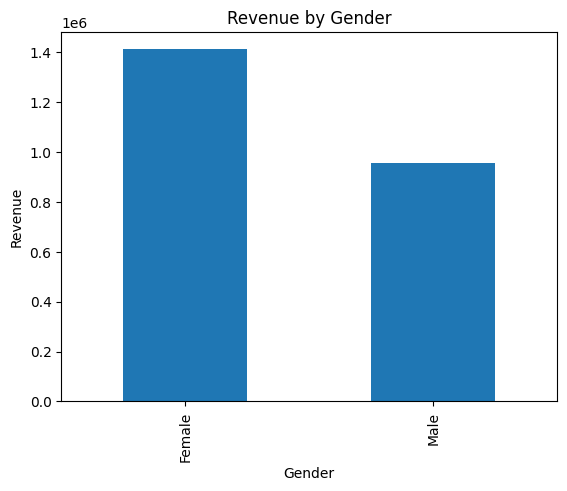

In [11]:
import matplotlib.pyplot as plt

revenue_gender = df.groupby('gender')['revenue'].sum()

print(revenue_gender)

revenue_gender.plot(kind='bar')
plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")
plt.show()

In [12]:
df['age_group'].value_counts()

age_group
Senior        367
Middle Age    289
Adult         185
Young         159
Name: count, dtype: int64

In [13]:
df.groupby('age_group')['quantity'].sum()

age_group
Adult          553
Middle Age     892
Senior        1057
Young          479
Name: quantity, dtype: int64

In [14]:
df.groupby('age_group')['revenue'].sum()

age_group
Adult         402876.49
Middle Age    704891.38
Senior        901446.83
Young         356153.07
Name: revenue, dtype: float64

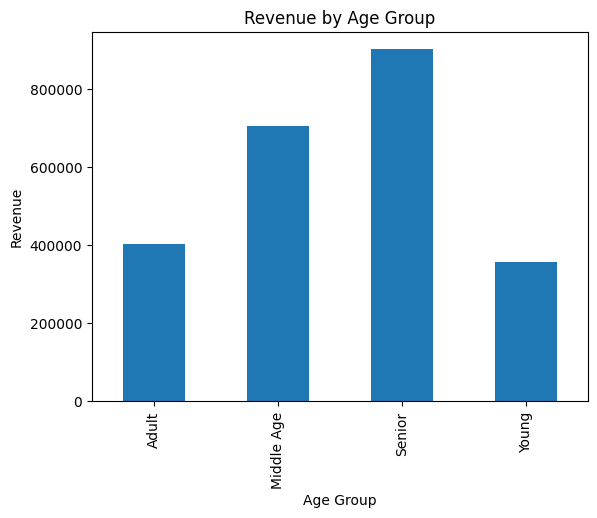

In [15]:
import matplotlib.pyplot as plt

age_revenue = df.groupby('age_group')['revenue'].sum()

age_revenue.plot(kind='bar')
plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.show()

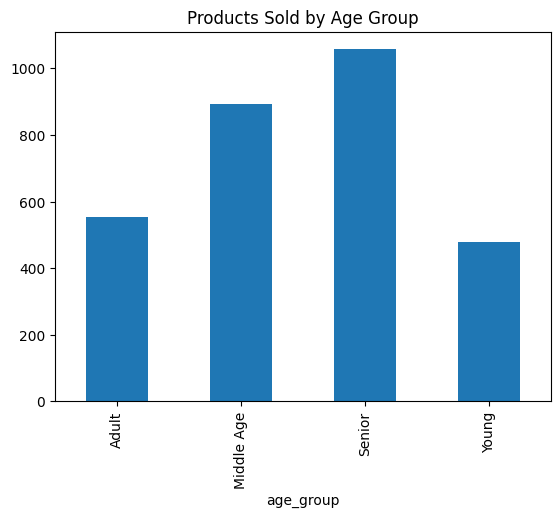

In [16]:
age_quantity = df.groupby('age_group')['quantity'].sum()

age_quantity.plot(kind='bar')
plt.title("Products Sold by Age Group")
plt.show()

In [17]:
df.groupby('category')['quantity'].sum().sort_values(ascending=False)

category
Clothing           977
Cosmetics          473
Food & Beverage    358
Toys               324
Shoes              312
Souvenir           213
Books              196
Technology         128
Name: quantity, dtype: int64

In [18]:
df.groupby('category')['revenue'].sum().sort_values(ascending=False)

category
Clothing           1048179.44
Shoes               685394.14
Technology          493500.00
Cosmetics            69081.34
Toys                 42362.88
Books                10574.70
Souvenir              9559.95
Food & Beverage       6715.32
Name: revenue, dtype: float64

In [19]:
df.groupby(['category','gender'])['revenue'].sum()

category         gender
Books            Female      5999.40
                 Male        4575.30
Clothing         Female    650573.44
                 Male      397606.00
Cosmetics        Female     44766.66
                 Male       24314.68
Food & Beverage  Female      4121.24
                 Male        2594.08
Shoes            Female    381708.12
                 Male      303686.02
Souvenir         Female      6533.61
                 Male        3026.34
Technology       Female    286650.00
                 Male      206850.00
Toys             Female     28528.64
                 Male       13834.24
Name: revenue, dtype: float64

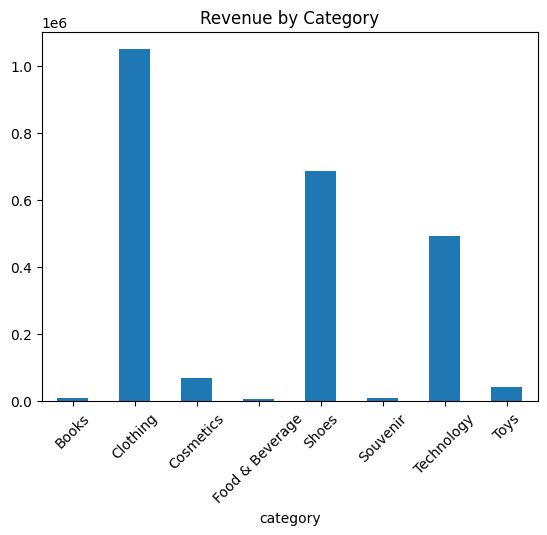

In [20]:
import matplotlib.pyplot as plt

category_revenue = df.groupby('category')['revenue'].sum()

category_revenue.plot(kind='bar')
plt.title("Revenue by Category")
plt.xticks(rotation=45)
plt.show()

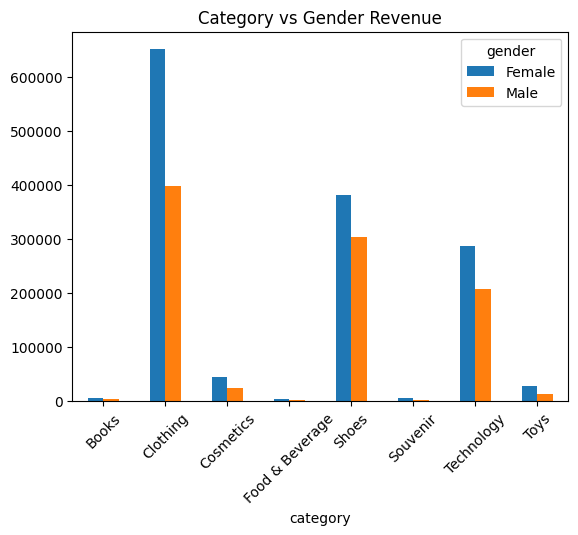

In [21]:
df.groupby(['category','gender'])['revenue'].sum().unstack().plot(kind='bar')
plt.title("Category vs Gender Revenue")
plt.xticks(rotation=45)
plt.show()

In [22]:
df['payment_method'].value_counts()


payment_method
Cash           420
Credit Card    366
Debit Card     214
Name: count, dtype: int64

In [23]:
df.groupby('payment_method')['revenue'].sum()

payment_method
Cash           1041239.48
Credit Card     770272.60
Debit Card      553855.69
Name: revenue, dtype: float64

In [24]:
df.groupby(['payment_method','gender'])['revenue'].sum()

payment_method  gender
Cash            Female    679474.93
                Male      361764.55
Credit Card     Female    427479.96
                Male      342792.64
Debit Card      Female    301926.22
                Male      251929.47
Name: revenue, dtype: float64

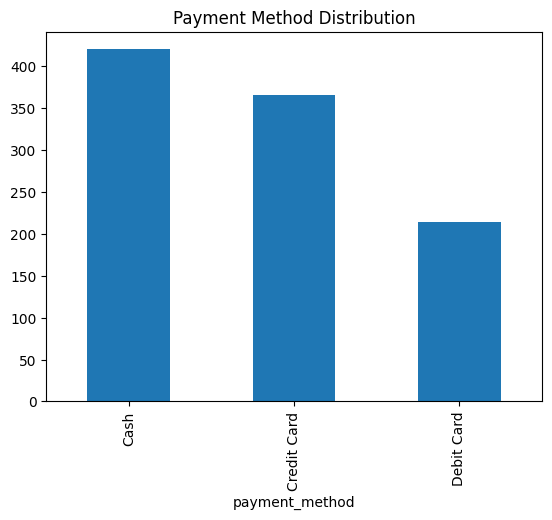

In [25]:
df['payment_method'].value_counts().plot(kind='bar')
plt.title("Payment Method Distribution")
plt.show()

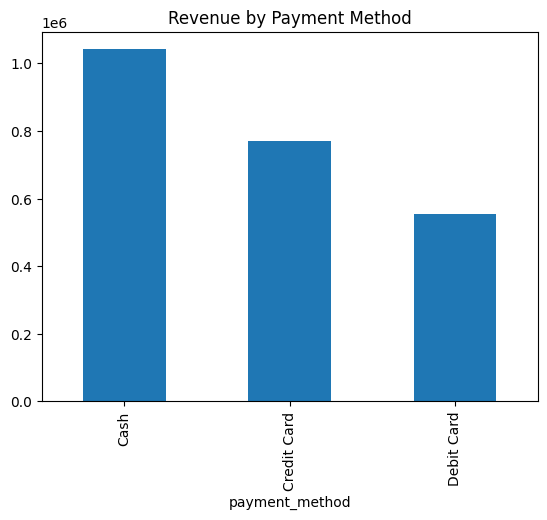

In [26]:
payment_revenue = df.groupby('payment_method')['revenue'].sum()

payment_revenue.plot(kind='bar')
plt.title("Revenue by Payment Method")
plt.show()

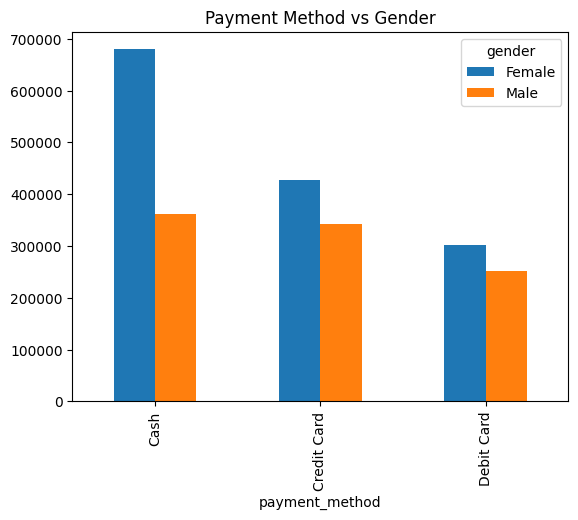

In [27]:
df.groupby(['payment_method','gender'])['revenue'].sum().unstack().plot(kind='bar')
plt.title("Payment Method vs Gender")
plt.show()